
Testing database size: 1000 images/objects
Feature dimension: 256D | Queries per trial: 100 | Trials: 5 | Top-k: 10
Trial 1/5 | Linear: 0.2079 ms | KD query: 0.4141 ms | LSH query: 0.2625 ms | LSH recall: 64.70%
Trial 2/5 | Linear: 0.1777 ms | KD query: 0.4233 ms | LSH query: 0.1991 ms | LSH recall: 63.30%
Trial 3/5 | Linear: 0.1736 ms | KD query: 0.4173 ms | LSH query: 0.2316 ms | LSH recall: 66.60%
Trial 4/5 | Linear: 0.1698 ms | KD query: 0.4138 ms | LSH query: 0.2234 ms | LSH recall: 69.30%
Trial 5/5 | Linear: 0.1799 ms | KD query: 0.4470 ms | LSH query: 0.2337 ms | LSH recall: 68.80%
----------------------------------------------------------------------------
Summary for N=1000
Linear Scan query median: 0.1777 ms
KD-Tree build median:     11.8557 ms
KD-Tree query median:     0.4173 ms
LSH build median:         9.5135 ms
LSH query median:         0.2316 ms
LSH Recall@10:           66.54%
LSH avg candidates:       113.03

Testing database size: 5000 images/objects
Feature dimension

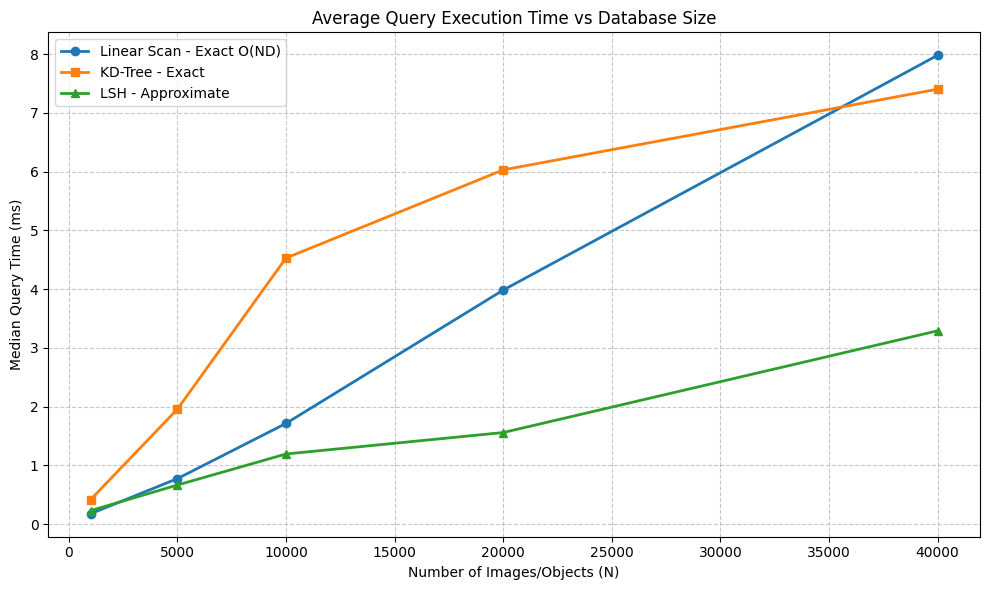

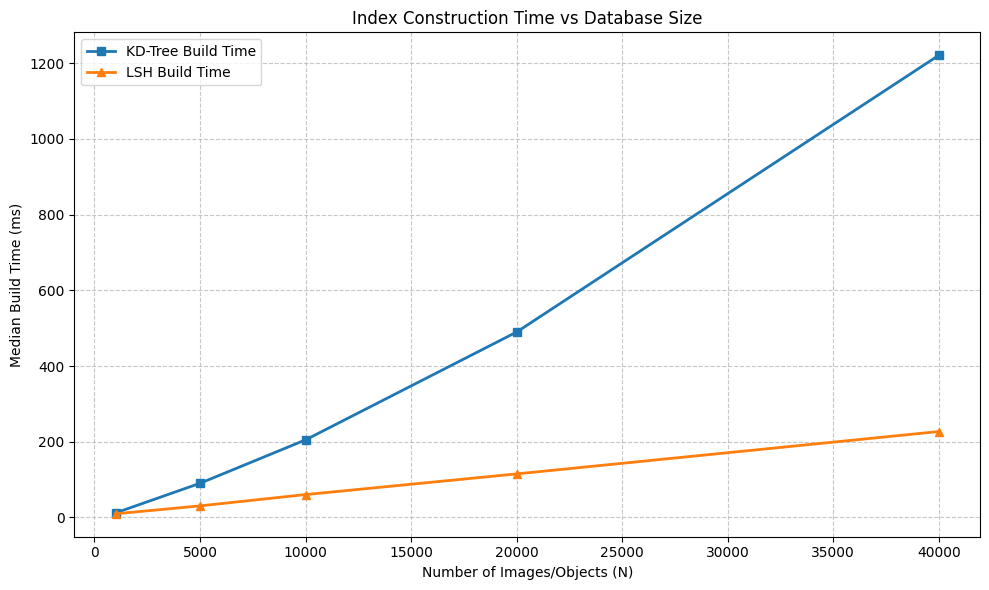

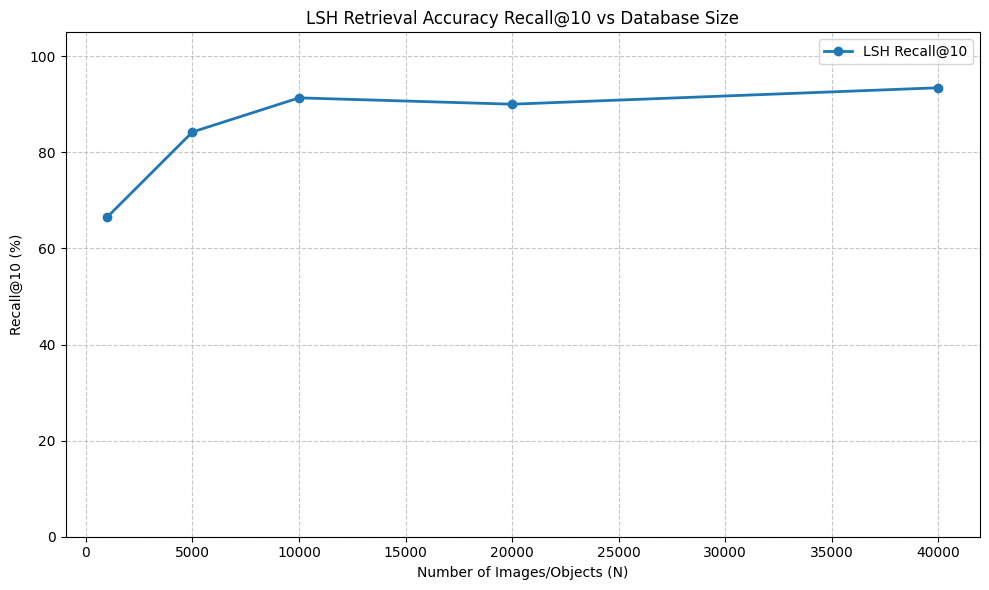

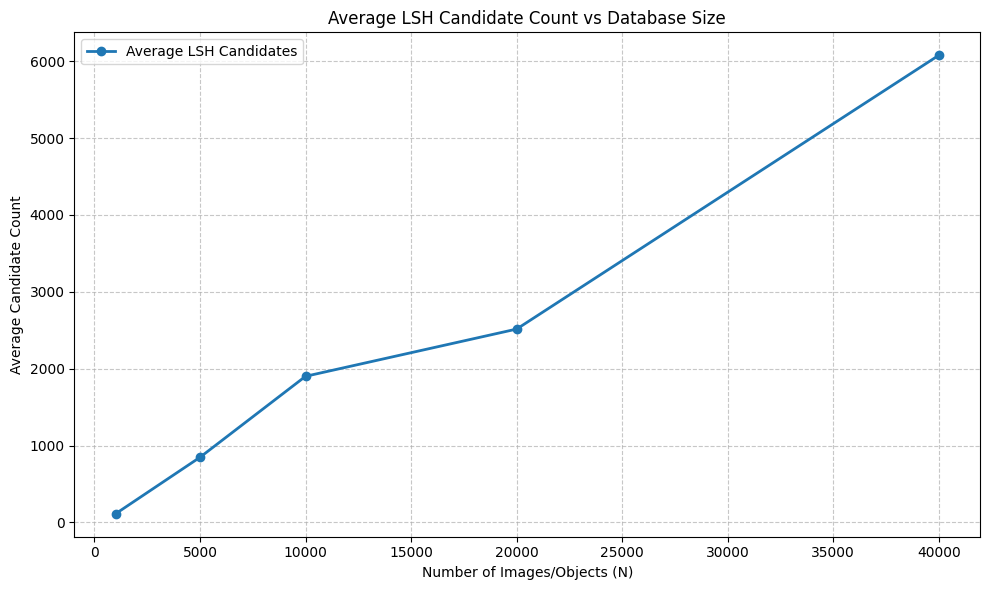


Experiment completed.
Saved files:
1. experiment_results_summary.csv
2. experiment_results_raw_trials.csv
3. query_time_comparison.png
4. build_time_comparison.png
5. lsh_recall_at_k.png
6. lsh_candidate_count.png


In [3]:
"""
TDA6323 Algorithm Design and Analysis
Project: Sorting Images/Objects: A Performance Study of Similarity-Based Algorithms
Using High-Dimensional Features

Final recommended experiment version.

Algorithms compared:
1. Exact Search / Linear Scan
2. KD-Tree
3. Locality-Sensitive Hashing (LSH)

Key design choices:
- Uses sklearn load_digits() as a real image-feature base dataset.
- Enlarges dataset using noise-based augmentation for scalability testing.
- Expands 64D image vectors into 256D high-dimensional feature vectors.
- Uses repeated trials and median timing to reduce noise.
- Separates index build time from query execution time.
"""

import csv
import gc
import time
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KDTree


# =========================================================
# Experiment settings
# =========================================================
RANDOM_SEED = 42

DATA_SIZES = [1000, 5000, 10000, 20000, 40000]
TARGET_DIMENSION = 256
K_NEIGHBORS = 10

# More queries + repeated trials make the graph more stable.
NUM_QUERIES = 100
NUM_TRIALS = 5
WARMUP_QUERIES = 10

# Dataset augmentation settings
AUGMENT_NOISE_STD = 0.03
QUERY_NOISE_STD = 0.02

# Final recommended LSH setting:
# This gives a clearer speed-vs-accuracy trade-off than HASH_SIZE = 10.
LSH_NUM_TABLES = 10
LSH_HASH_SIZE = 14


# =========================================================
# Utility functions
# =========================================================
def l2_normalize(x: np.ndarray) -> np.ndarray:
    """Normalize each feature vector to unit length."""
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / (norm + 1e-12)


def expand_to_high_dimension(
    x: np.ndarray,
    target_dim: int,
    seed: int = RANDOM_SEED
) -> np.ndarray:
    """
    Convert original 64-dimensional digit-image vectors into higher-dimensional
    vectors. This simulates high-dimensional image/object descriptors.
    """
    original_dim = x.shape[1]

    if target_dim < original_dim:
        raise ValueError("target_dim must be greater than or equal to original feature dimension.")

    if target_dim == original_dim:
        return x.astype(np.float32)

    rng = np.random.default_rng(seed)
    extra_dim = target_dim - original_dim

    projection_matrix = rng.normal(
        loc=0.0,
        scale=1.0 / np.sqrt(original_dim),
        size=(original_dim, extra_dim)
    ).astype(np.float32)

    projected_features = np.tanh(x @ projection_matrix)
    high_dim_features = np.hstack([x, projected_features])

    return high_dim_features.astype(np.float32)


def prepare_image_data(
    target_size: int,
    target_dim: int = TARGET_DIMENSION,
    seed: int = RANDOM_SEED
) -> np.ndarray:
    """
    Prepare the image/object feature database.

    Report wording:
    The experiment uses the sklearn handwritten digit image dataset as the real
    base image dataset. To test scalability, the dataset is enlarged using
    noise-based augmentation and then expanded into 256-dimensional feature vectors.
    """
    rng = np.random.default_rng(seed + target_size)

    digits = load_digits()
    base_data = digits.data.astype(np.float32) / 16.0

    if target_size > len(base_data):
        repeat_times = (target_size // len(base_data)) + 1
        expanded_data = np.tile(base_data, (repeat_times, 1))[:target_size]

        noise = rng.normal(
            loc=0.0,
            scale=AUGMENT_NOISE_STD,
            size=expanded_data.shape
        ).astype(np.float32)

        expanded_data = np.clip(expanded_data + noise, 0.0, 1.0)
    else:
        selected_indices = rng.choice(len(base_data), size=target_size, replace=False)
        expanded_data = base_data[selected_indices]

    high_dim_data = expand_to_high_dimension(
        expanded_data,
        target_dim=target_dim,
        seed=seed
    )

    high_dim_data = l2_normalize(high_dim_data)
    return high_dim_data.astype(np.float32)


def generate_queries(
    dataset: np.ndarray,
    num_queries: int,
    seed: int
) -> np.ndarray:
    """
    Generate query vectors from existing image features with small noise.
    This simulates image/object queries that are similar but not exactly identical.
    """
    rng = np.random.default_rng(seed)

    query_indices = rng.choice(len(dataset), size=num_queries, replace=True)
    queries = dataset[query_indices].copy()

    noise = rng.normal(
        loc=0.0,
        scale=QUERY_NOISE_STD,
        size=queries.shape
    ).astype(np.float32)

    queries = queries + noise
    queries = l2_normalize(queries)

    return queries.astype(np.float32)


# =========================================================
# Algorithm 1: Exact Search / Linear Scan
# =========================================================
def linear_scan_search(
    dataset: np.ndarray,
    query: np.ndarray,
    k: int = K_NEIGHBORS
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Exact nearest-neighbour search using brute-force comparison.

    Design technique:
    - Exhaustive search / brute force

    Theoretical query complexity:
    - O(ND), where N is database size and D is feature dimension.
    """
    k = min(k, len(dataset))

    diff = dataset - query
    squared_distances = np.einsum("ij,ij->i", diff, diff)

    candidate_indices = np.argpartition(squared_distances, k - 1)[:k]
    sorted_local_order = np.argsort(squared_distances[candidate_indices])
    nearest_indices = candidate_indices[sorted_local_order]

    return nearest_indices, np.sqrt(squared_distances[nearest_indices])


# =========================================================
# Algorithm 2: KD-Tree
# =========================================================
class KDTreeSearcher:
    """
    Exact nearest-neighbour search using KD-Tree.

    Design technique:
    - Divide and conquer / spatial partitioning

    Theoretical complexity:
    - Build: O(N log N)
    - Query: average O(log N) in low dimensions, but may degrade in high dimensions.
    """

    def __init__(self, dataset: np.ndarray):
        self.dataset = dataset
        self.tree = KDTree(dataset)

    def search(
        self,
        query: np.ndarray,
        k: int = K_NEIGHBORS
    ) -> Tuple[np.ndarray, np.ndarray]:
        k = min(k, len(self.dataset))
        distances, indices = self.tree.query(query.reshape(1, -1), k=k)
        return indices[0], distances[0]


# =========================================================
# Algorithm 3: Random Hyperplane LSH
# =========================================================
class RandomHyperplaneLSH:
    """
    Approximate nearest-neighbour search using random hyperplane LSH.

    Design technique:
    - Randomized hashing / approximate similarity search

    Theoretical complexity:
    - Build: approximately O(LNDH)
    - Query: sub-linear in practice, depending on the candidate set size.
    """

    def __init__(
        self,
        dataset: np.ndarray,
        num_hash_tables: int = LSH_NUM_TABLES,
        hash_size: int = LSH_HASH_SIZE,
        seed: int = RANDOM_SEED
    ):
        self.dataset = dataset
        self.num_hash_tables = num_hash_tables
        self.hash_size = hash_size
        self.dim = dataset.shape[1]
        self.rng = np.random.default_rng(seed)

        if hash_size > 32:
            raise ValueError("This simple implementation supports hash_size <= 32.")

        self.projections = self.rng.normal(
            loc=0.0,
            scale=1.0,
            size=(num_hash_tables, hash_size, self.dim)
        ).astype(np.float32)

        self.hash_tables: List[Dict[int, List[int]]] = [
            dict() for _ in range(num_hash_tables)
        ]

        self._build_hash_tables()

    def _hash_batch(self, points: np.ndarray, table_idx: int) -> np.ndarray:
        projection = self.projections[table_idx]
        bits = (points @ projection.T) > 0

        powers = (1 << np.arange(self.hash_size, dtype=np.uint32))
        codes = bits.astype(np.uint32) @ powers

        return codes.astype(np.uint32)

    def _hash_point(self, point: np.ndarray, table_idx: int) -> int:
        return int(self._hash_batch(point.reshape(1, -1), table_idx)[0])

    def _build_hash_tables(self) -> None:
        for table_idx in range(self.num_hash_tables):
            codes = self._hash_batch(self.dataset, table_idx)
            table = self.hash_tables[table_idx]

            for data_index, code in enumerate(codes):
                code = int(code)

                if code not in table:
                    table[code] = []

                table[code].append(data_index)

    def search(
        self,
        query: np.ndarray,
        k: int = K_NEIGHBORS,
        return_candidate_count: bool = False
    ):
        k = min(k, len(self.dataset))
        candidates = set()

        for table_idx in range(self.num_hash_tables):
            code = self._hash_point(query, table_idx)
            bucket = self.hash_tables[table_idx].get(code, [])
            candidates.update(bucket)

        candidate_count = len(candidates)

        # Fallback only happens when LSH retrieves no candidates.
        # This prevents invalid empty results but should be rare with the chosen parameters.
        if candidate_count == 0:
            indices, distances = linear_scan_search(self.dataset, query, k)

            if return_candidate_count:
                return indices, distances, len(self.dataset)

            return indices, distances

        candidate_indices = np.array(list(candidates), dtype=np.int32)
        candidate_points = self.dataset[candidate_indices]

        diff = candidate_points - query
        squared_distances = np.einsum("ij,ij->i", diff, diff)

        actual_k = min(k, len(candidate_indices))
        local_top_indices = np.argpartition(squared_distances, actual_k - 1)[:actual_k]
        local_sorted_order = np.argsort(squared_distances[local_top_indices])
        local_best = local_top_indices[local_sorted_order]

        final_indices = candidate_indices[local_best]
        final_distances = np.sqrt(squared_distances[local_best])

        if return_candidate_count:
            return final_indices, final_distances, candidate_count

        return final_indices, final_distances


# =========================================================
# Evaluation helper functions
# =========================================================
def recall_at_k(
    exact_indices: np.ndarray,
    approx_indices: np.ndarray,
    k: int = K_NEIGHBORS
) -> float:
    """Calculate how many approximate results overlap with exact top-k results."""
    exact_set = set(exact_indices[:k])
    approx_set = set(approx_indices[:k])

    return len(exact_set.intersection(approx_set)) / k


def timed_queries(search_function, queries: np.ndarray, k: int = K_NEIGHBORS):
    """
    Run query timing after a short warm-up.
    Returns average query time in milliseconds and all query results.
    """
    warmup_count = min(WARMUP_QUERIES, len(queries))

    for query in queries[:warmup_count]:
        search_function(query, k)

    results = []
    start_ns = time.perf_counter_ns()

    for query in queries:
        results.append(search_function(query, k))

    elapsed_ms = (time.perf_counter_ns() - start_ns) / 1_000_000
    avg_ms = elapsed_ms / len(queries)

    return avg_ms, results


def median(values: List[float]) -> float:
    return float(np.median(np.array(values, dtype=np.float64)))


def mean(values: List[float]) -> float:
    return float(np.mean(np.array(values, dtype=np.float64)))


# =========================================================
# Main experiment
# =========================================================
def run_experiment():
    summary_results = []
    raw_trial_results = []

    for size in DATA_SIZES:
        print("\n" + "=" * 76)
        print(f"Testing database size: {size} images/objects")
        print(
            f"Feature dimension: {TARGET_DIMENSION}D | "
            f"Queries per trial: {NUM_QUERIES} | "
            f"Trials: {NUM_TRIALS} | "
            f"Top-k: {K_NEIGHBORS}"
        )
        print("=" * 76)

        trial_linear_query = []
        trial_kdtree_build = []
        trial_kdtree_query = []
        trial_kdtree_recall = []
        trial_lsh_build = []
        trial_lsh_query = []
        trial_lsh_recall = []
        trial_lsh_candidates = []

        for trial in range(NUM_TRIALS):
            trial_seed = RANDOM_SEED + (size * 10) + trial

            dataset = prepare_image_data(
                target_size=size,
                target_dim=TARGET_DIMENSION,
                seed=trial_seed
            )

            queries = generate_queries(
                dataset=dataset,
                num_queries=NUM_QUERIES,
                seed=trial_seed + 999
            )

            # -------------------------------
            # Linear Scan
            # -------------------------------
            linear_avg_ms, linear_results = timed_queries(
                lambda q, k: linear_scan_search(dataset, q, k),
                queries,
                K_NEIGHBORS
            )

            exact_indices_list = [result[0] for result in linear_results]

            # -------------------------------
            # KD-Tree build and query
            # -------------------------------
            gc.collect()
            start_build_ns = time.perf_counter_ns()
            kdtree_searcher = KDTreeSearcher(dataset)
            kdtree_build_ms = (time.perf_counter_ns() - start_build_ns) / 1_000_000

            kdtree_avg_ms, kdtree_results = timed_queries(
                lambda q, k: kdtree_searcher.search(q, k),
                queries,
                K_NEIGHBORS
            )

            kdtree_recalls = [
                recall_at_k(exact_indices_list[i], kdtree_results[i][0], K_NEIGHBORS)
                for i in range(NUM_QUERIES)
            ]

            # -------------------------------
            # LSH build and query
            # -------------------------------
            gc.collect()
            start_build_ns = time.perf_counter_ns()
            lsh_searcher = RandomHyperplaneLSH(
                dataset=dataset,
                num_hash_tables=LSH_NUM_TABLES,
                hash_size=LSH_HASH_SIZE,
                seed=trial_seed + 123
            )
            lsh_build_ms = (time.perf_counter_ns() - start_build_ns) / 1_000_000

            # Warm-up
            for query in queries[:min(WARMUP_QUERIES, len(queries))]:
                lsh_searcher.search(query, K_NEIGHBORS, return_candidate_count=True)

            lsh_query_results = []
            lsh_candidate_counts = []

            start_query_ns = time.perf_counter_ns()

            for query in queries:
                indices, distances, candidate_count = lsh_searcher.search(
                    query,
                    K_NEIGHBORS,
                    return_candidate_count=True
                )
                lsh_query_results.append((indices, distances))
                lsh_candidate_counts.append(candidate_count)

            lsh_avg_ms = ((time.perf_counter_ns() - start_query_ns) / 1_000_000) / NUM_QUERIES

            lsh_recalls = [
                recall_at_k(exact_indices_list[i], lsh_query_results[i][0], K_NEIGHBORS)
                for i in range(NUM_QUERIES)
            ]

            # Store trial results
            trial_linear_query.append(linear_avg_ms)
            trial_kdtree_build.append(kdtree_build_ms)
            trial_kdtree_query.append(kdtree_avg_ms)
            trial_kdtree_recall.append(mean(kdtree_recalls) * 100)
            trial_lsh_build.append(lsh_build_ms)
            trial_lsh_query.append(lsh_avg_ms)
            trial_lsh_recall.append(mean(lsh_recalls) * 100)
            trial_lsh_candidates.append(mean(lsh_candidate_counts))

            raw_trial_results.append({
                "Database Size": size,
                "Trial": trial + 1,
                "Linear Query Avg (ms)": linear_avg_ms,
                "KDTree Build (ms)": kdtree_build_ms,
                "KDTree Query Avg (ms)": kdtree_avg_ms,
                "KDTree Recall@K (%)": mean(kdtree_recalls) * 100,
                "LSH Build (ms)": lsh_build_ms,
                "LSH Query Avg (ms)": lsh_avg_ms,
                "LSH Recall@K (%)": mean(lsh_recalls) * 100,
                "LSH Avg Candidates": mean(lsh_candidate_counts),
            })

            print(
                f"Trial {trial + 1}/{NUM_TRIALS} | "
                f"Linear: {linear_avg_ms:.4f} ms | "
                f"KD query: {kdtree_avg_ms:.4f} ms | "
                f"LSH query: {lsh_avg_ms:.4f} ms | "
                f"LSH recall: {mean(lsh_recalls) * 100:.2f}%"
            )

            del dataset, queries, kdtree_searcher, lsh_searcher
            gc.collect()

        summary = {
            "Database Size": size,
            "Feature Dimension": TARGET_DIMENSION,

            "Linear Query Median (ms)": median(trial_linear_query),

            "KDTree Build Median (ms)": median(trial_kdtree_build),
            "KDTree Query Median (ms)": median(trial_kdtree_query),
            "KDTree Recall@K Mean (%)": mean(trial_kdtree_recall),

            "LSH Build Median (ms)": median(trial_lsh_build),
            "LSH Query Median (ms)": median(trial_lsh_query),
            "LSH Recall@K Mean (%)": mean(trial_lsh_recall),
            "LSH Avg Candidates Mean": mean(trial_lsh_candidates),
        }

        summary_results.append(summary)

        print("-" * 76)
        print(f"Summary for N={size}")
        print(f"Linear Scan query median: {summary['Linear Query Median (ms)']:.4f} ms")
        print(f"KD-Tree build median:     {summary['KDTree Build Median (ms)']:.4f} ms")
        print(f"KD-Tree query median:     {summary['KDTree Query Median (ms)']:.4f} ms")
        print(f"LSH build median:         {summary['LSH Build Median (ms)']:.4f} ms")
        print(f"LSH query median:         {summary['LSH Query Median (ms)']:.4f} ms")
        print(f"LSH Recall@{K_NEIGHBORS}:           {summary['LSH Recall@K Mean (%)']:.2f}%")
        print(f"LSH avg candidates:       {summary['LSH Avg Candidates Mean']:.2f}")

    save_results_to_csv(summary_results, "experiment_results_summary.csv")
    save_results_to_csv(raw_trial_results, "experiment_results_raw_trials.csv")

    plot_query_time(summary_results)
    plot_build_time(summary_results)
    plot_lsh_recall(summary_results)
    plot_lsh_candidates(summary_results)

    print("\n" + "=" * 76)
    print("Experiment completed.")
    print("Saved files:")
    print("1. experiment_results_summary.csv")
    print("2. experiment_results_raw_trials.csv")
    print("3. query_time_comparison.png")
    print("4. build_time_comparison.png")
    print("5. lsh_recall_at_k.png")
    print("6. lsh_candidate_count.png")
    print("=" * 76)

    return summary_results, raw_trial_results


# =========================================================
# Save and plot results
# =========================================================
def save_results_to_csv(results: List[Dict], filename: str) -> None:
    if not results:
        return

    fieldnames = list(results[0].keys())

    with open(filename, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)


def plot_query_time(results: List[Dict]) -> None:
    sizes = [row["Database Size"] for row in results]
    linear_times = [row["Linear Query Median (ms)"] for row in results]
    kdtree_times = [row["KDTree Query Median (ms)"] for row in results]
    lsh_times = [row["LSH Query Median (ms)"] for row in results]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, linear_times, marker="o", linewidth=2, label="Linear Scan - Exact O(ND)")
    plt.plot(sizes, kdtree_times, marker="s", linewidth=2, label="KD-Tree - Exact")
    plt.plot(sizes, lsh_times, marker="^", linewidth=2, label="LSH - Approximate")

    plt.title("Average Query Execution Time vs Database Size")
    plt.xlabel("Number of Images/Objects (N)")
    plt.ylabel("Median Query Time (ms)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("query_time_comparison.png", dpi=300)
    plt.show()


def plot_build_time(results: List[Dict]) -> None:
    sizes = [row["Database Size"] for row in results]
    kdtree_build = [row["KDTree Build Median (ms)"] for row in results]
    lsh_build = [row["LSH Build Median (ms)"] for row in results]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, kdtree_build, marker="s", linewidth=2, label="KD-Tree Build Time")
    plt.plot(sizes, lsh_build, marker="^", linewidth=2, label="LSH Build Time")

    plt.title("Index Construction Time vs Database Size")
    plt.xlabel("Number of Images/Objects (N)")
    plt.ylabel("Median Build Time (ms)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("build_time_comparison.png", dpi=300)
    plt.show()


def plot_lsh_recall(results: List[Dict]) -> None:
    sizes = [row["Database Size"] for row in results]
    lsh_recall = [row["LSH Recall@K Mean (%)"] for row in results]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, lsh_recall, marker="o", linewidth=2, label=f"LSH Recall@{K_NEIGHBORS}")

    plt.title(f"LSH Retrieval Accuracy Recall@{K_NEIGHBORS} vs Database Size")
    plt.xlabel("Number of Images/Objects (N)")
    plt.ylabel(f"Recall@{K_NEIGHBORS} (%)")
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("lsh_recall_at_k.png", dpi=300)
    plt.show()


def plot_lsh_candidates(results: List[Dict]) -> None:
    sizes = [row["Database Size"] for row in results]
    candidates = [row["LSH Avg Candidates Mean"] for row in results]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, candidates, marker="o", linewidth=2, label="Average LSH Candidates")

    plt.title("Average LSH Candidate Count vs Database Size")
    plt.xlabel("Number of Images/Objects (N)")
    plt.ylabel("Average Candidate Count")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("lsh_candidate_count.png", dpi=300)
    plt.show()


if __name__ == "__main__":
    run_experiment()
